### Club Veille DuckDB
Idées de Plan : 
1. Lecture directe de fichiers (zero-copy)
2. Requêtes Fédérées
3. Convivialité SQL pour le Dataframe
4. Benchmark avec Pandas & Polars
5. DuckDB CLI
6. Cas d'usage : Analyse exploratoire de dataset
5. Cas d'usage : Small ETL on a laptop


Dataset : New York Yellow taxi trips 2023 https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page 
Inspirations
- https://medium.com/@connect.hashblock/duckdb-in-7-minutes-7-mind-blowing-demos-680aeec4ec14


In [3]:
import duckdb as d
import pandas as pd
import polars as pl
import time

In [6]:
parquet_filepath = '00_data_sources/yellow_tripdata_2023-01.parquet'

In [7]:
# #Download NYC taxi trip data from 2025
# for month in range(1, 10):
#     month_str = str(month).zfill(2)
#     source_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-{month_str}.parquet"
#     destination_filepath = f'00_data_sources/yellow_tripdata_2025-{month_str}.parquet'
#     !wget -O {destination_filepath} {source_url}

In [4]:
# Merge data from all 2024 files into a single parquet file
parquet_files_pattern = "00_data_sources/2024_trips/yellow_tripdata_2024-*.parquet"

merged_2024_data = d.sql(
    f"""
    SELECT *
    FROM read_parquet('{parquet_files_pattern}')
    """
)

nb_lines_2024 = merged_2024_data.count(
    "*")
print(f"Number of lines in 2024 data: {nb_lines_2024}")

merged_2024_data.write_parquet('00_data_sources/yellow_tripdata_full_2024.parquet')

Number of lines in 2024 data: ┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     41169720 │
└──────────────┘



### 1. Lecture Directe de Fichiers (Zero-Copy)

##### a. Interroger directement des fichiers (CSV, Parquet, JSON, etc.) sans les charger au préalable : la fonction READ_PARQUET().
Note : duckdb crée automatiqmenet une session duckdb, sans déclaration.

Pour expliciter : con = d.connect(database=':memory:', read_only=False)

In [8]:
### Interrogez directement des fichiers (CSV, Parquet, JSON, etc.) sans les charger au préalable : la fonction READ_PARQUET().

# Read the Parquet file into a Relation
taxi_data_202301 = d.read_parquet(parquet_filepath)

# Print the first 5 rows (materializes to a Pandas DataFrame by default in the REPL)
print(taxi_data_202301.limit(5))


┌──────────┬──────────────────────┬───────────────────────┬─────────────────┬───────────────┬────────────┬────────────────────┬──────────────┬──────────────┬──────────────┬─────────────┬────────┬─────────┬────────────┬──────────────┬───────────────────────┬──────────────┬──────────────────────┬─────────────┐
│ VendorID │ tpep_pickup_datetime │ tpep_dropoff_datetime │ passenger_count │ trip_distance │ RatecodeID │ store_and_fwd_flag │ PULocationID │ DOLocationID │ payment_type │ fare_amount │ extra  │ mta_tax │ tip_amount │ tolls_amount │ improvement_surcharge │ total_amount │ congestion_surcharge │ airport_fee │
│  int64   │      timestamp       │       timestamp       │     double      │    double     │   double   │      varchar       │    int64     │    int64     │    int64     │   double    │ double │ double  │   double   │    double    │        double         │    double    │        double        │   double    │
├──────────┼──────────────────────┼───────────────────────┼───────────

##### b. Exécuter des opérations SQL directement sur le fichier Parquet

In [ ]:
result = d.sql(
    """
    SELECT COUNT(*) AS total_trips FROM taxi_data_202301
    """
)
print(result)

CatalogException: Catalog Error: Table with name taxi_data does not exist!
Did you mean "pg_database"?

In [ ]:
result2 = d.sql(
    """
    SELECT COUNT(*) AS total_trips,
    AVG(trip_distance) AS avg_distance,
    SUM(total_amount) AS total_revenue
    FROM taxi_data
    WHERE total_amount > 0 AND trip_distance > 0;
    """
)
print(result2)

┌─────────────┬───────────────────┬──────────────────┐
│ total_trips │   avg_distance    │  total_revenue   │
│    int64    │      double       │      double      │
├─────────────┼───────────────────┼──────────────────┤
│     2998642 │ 3.910143858453183 │ 82033717.9997885 │
└─────────────┴───────────────────┴──────────────────┘



#### 2. Requêtes Fédérées (Federated Queries)

Joindre des données provenant de différentes sources (fichiers locaux, S3, bases de données externes comme PostgreSQL via des extensions).

Démonstration : Joindre un fichier Parquet local avec une table dans une base de données PostgreSQL ou un DataFrame Pandas en mémoire.

In [ ]:
source_url_202302 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet"
source_url_202303 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet"
source_url_202304 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-04.parquet"
source_url_202305 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-05.parquet"

In [ ]:
# Read the Parquet directly from URL 
taxi_data_202302 = d.read_parquet(source_url_202302)

nb_rows = d.sql(
    """
    SELECT COUNT(*) AS total_rows_feb23 FROM taxi_data_202302;
    """
)

print(nb_rows)

┌──────────────────┐
│ total_rows_feb23 │
│      int64       │
├──────────────────┤
│          2913955 │
└──────────────────┘



### Join a local parquet file and a parquet file from a URL 


In [ ]:
# Join a local parquet file and a parquet file from a URL 
taxi_data_202303 = d.read_parquet(source_url_202303)

joined_data = d.sql(
    """
    SELECT *
    FROM taxi_data_202301 AS t1
    UNION ALL
    SELECT *
    FROM taxi_data_202302 AS t2
    UNION ALL
    SELECT *
    FROM taxi_data_202303 AS t3
    """
)

nb_trips_per_month = d.sql(
    """
    SELECT
        COUNT(*) AS total_trips,
        strftime(tpep_pickup_datetime , '%Y-%m') AS trip_month
    FROM joined_data
    WHERE trip_month IN ('2023-01', '2023-02', '2023-03')
    GROUP BY trip_month
    ORDER BY trip_month;
    """
)
print(nb_trips_per_month)


┌─────────────┬────────────┐
│ total_trips │ trip_month │
│    int64    │  varchar   │
├─────────────┼────────────┤
│     3066726 │ 2023-01    │
│     2914003 │ 2023-02    │
│     3403619 │ 2023-03    │
└─────────────┴────────────┘



### Joindre tous les fichiers qui correspondent au même motif de nommage via une requête SQL


In [7]:
start_time = time.time()

full_taxi_data_2025 = d.sql(
    """
    SELECT * 
    FROM read_parquet("00_data_sources/yellow_tripdata_2025-*.parquet")
    """
)

nb_trips_2025 = d.sql(
    """
    SELECT COUNT(*) AS total_trips_2025
    FROM full_taxi_data_2025 ;
    """
)

execution_time_duckdb = time.time() - start_time
print(nb_trips_2025)
#format execution time
print(f"Execution time DuckDB: {execution_time_duckdb:.4f} seconds")


┌──────────────────┐
│ total_trips_2025 │
│      int64       │
├──────────────────┤
│         35807453 │
└──────────────────┘

Execution time DuckDB: 0.0035 seconds


### Comparaison avec Polars


In [8]:
start_time = time.time()

# Charger et concaténer les fichiers Parquet avec Polars
parquet_filepaths_2025 = [
    f"00_data_sources/yellow_tripdata_2025-{str(month).zfill(2)}.parquet"
    for month in range(1, 10)
]
polars_dfs = [pl.read_parquet(fp) for fp in parquet_filepaths_2025]
full_taxi_data_2025_polars = pl.concat(polars_dfs)

execution_time_polars = time.time() - start_time

# Vérifier le nombre total de trajets avec Polars
total_trips_polars = full_taxi_data_2025_polars.shape[0]
print(f"Total trips in 2025 (Polars): {total_trips_polars}")
print(f"Execution time Polars: {execution_time_polars:.4f} seconds")


Total trips in 2025 (Polars): 35807453
Execution time Polars: 35.3502 seconds


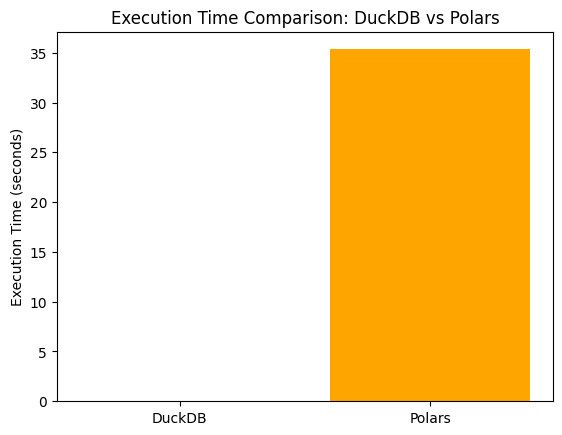

In [9]:
# Plot comparison of execution times
import matplotlib.pyplot as plt
labels = ['DuckDB', 'Polars']
times = [execution_time_duckdb, execution_time_polars]
plt.bar(labels, times, color=['blue', 'orange'])
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: DuckDB vs Polars')
plt.show()


#### 3. 🚀 Intérêt de l'Intégration DuckDB + Pandas
m
Exécuter des requêtes SQL sur des DataFrames (Pandas, Polars) directement, sans conversion intermédiaire complexe.

Démonstration : Utiliser la méthode duckdb.sql() sur un DataFrame Python.b

L'intégration vous permet d'alterner facilement entre les deux outils dans un seul script :

- Pandas : Charger et nettoyer rapidement les données initiales.
- DuckDB : Exécuter une jointure ou une agrégation complexe en quelques millisecondes.
- Pandas : Récupérer le résultat (qui est automatiquement un DataFrame Pandas) et le visualiser (Matplotlib, Seaborn) ou l'utiliser comme entrée pour un modèle.

In [26]:
### Démonstration :
# Pandas : Charger et nettoyer rapidement les données initiales.

# DuckDB : Exécuter une jointure ou une agrégation complexe en quelques millisecondes.

# Pandas : Récupérer le résultat (qui est automatiquement un DataFrame Pandas) et le visualiser (Matplotlib, Seaborn) ou l'utiliser comme entrée pour un modèle.

#### 4. Benchmark avec Pandas & Polars

#### 5. Cas d'usage : Analyse exploratoire de dataset

POC de Transformation ETL/ELT local